# 01: Quickstart – Fit Uncalibrated MMM
## Introduction
### Business Context
Marketing Mix Modeling (MMM) helps companies understand which marketing channels drive sales and optimize budget allocation. However, traditional observational MMM faces a critical challenge: **correlation ≠ causation**.

Without experimental validation, models may:
- Confuse correlation with causation (e.g., high TV spend during holidays → model credits TV for holiday sales)
- Overestimate ROI due to lack of external constraints
- Produce wide uncertainty intervals that make business decisions difficult

This notebook establishes a **baseline uncalibrated model using only the (simulated) observational data** to demonstrate these challenges before addressing them through experimental calibration in Notebook 02.

### Why Start Uncalibrated?
Starting with an uncalibrated model serves two purposes:
1. **Diagnostic baseline**: Shows what purely observational data can (and cannot) tell us
2. **Validation target**: Provides a reference for measuring calibration impact

As we'll see, this model achieves strong statistical convergence but suffers from the limitations inherent to all observational studies.

### Key Skills Demonstrated
- Statistical sophistication: Understanding prior → posterior inference
- Intellectual honesty: Calling out model limitations before being asked
- Production thinking: Clean, reproducible pipelines

# Setup

In [7]:
# Imports + path
import sys
from pathlib import Path

# Make src importable
repo_root = Path("..").resolve()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Repo root:", repo_root)

Repo root: /Users/asamitakeuchi/bayesian_mmm_calibrated_with_incrementality


In [11]:
# Core imports
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%pip install -U scikit-learn
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

from mmm_calibration.config import MMMConfig, PathsConfig
from mmm_calibration.preprocessing import load_raw_data, build_model_matrix
from mmm_calibration.model import fit_mmm
from mmm_calibration.diagnostics import basic_model_report
from mmm_calibration.adstock import geometric_adstock_2d
from mmm_calibration.saturation import hill_saturation

/opt/anaconda3/envs/pymc_mmm/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Note: you may need to restart the kernel to use updated packages.


In [12]:
# Check the version
print(sys.executable)
print(np.__version__)

/opt/anaconda3/envs/pymc_mmm/bin/python
2.3.5


In [14]:
import sys, numpy as np, pymc as pm, pytensor
print("python:", sys.version)
print("exe:", sys.executable)
print("numpy:", np.__version__)
print("pymc:", pm.__version__)
print("pytensor:", pytensor.__version__)

python: 3.11.11 | packaged by conda-forge | (main, Mar  3 2025, 20:44:07) [Clang 18.1.8 ]
exe: /opt/anaconda3/envs/pymc_mmm/bin/python
numpy: 2.3.5
pymc: 5.27.1
pytensor: 2.37.0


## 1. Load and Explore Data
We're using **synthetic data** with known ground truth to validate methodology.<br/>
**Real-world note:** In production, you'd validate data quality, check for anomalies, and document any preprocessing decisions

### Dataset Overview (Pre-Calibration)

This notebook uses a **synthetic weekly marketing dataset** designed to resemble a typical
MMM setup prior to incrementality calibration.

**Time horizon**
- Weekly data spanning ~3 years (156 weeks)

**Geography**
- National-level aggregated data (no geo split at this stage)
- Geo variation is introduced later through simulated experiments for calibration

**Datasets**

1. **marketing_spend.csv**
   - Granularity: weekly × channel
   - Columns: `date`, `channel`, `spend`
   - Represents media investment across channels (e.g., search, social, youtube)
   - Scale: tens of thousands of dollars per week per channel

2. **outcome_sales.csv**
   - Granularity: weekly
   - Columns: `date`, `y`
   - Total business outcome (sales or conversions)
   - Scale: tens of thousands of units per week

3. **controls.csv**
   - Granularity: weekly
   - Columns: `price_index`, `promo`, `macro_index`, `seasonality`
   - Captures non-media drivers of demand

This dataset intentionally reflects a **typical observational MMM setting**
where causal effects are not directly identifiable prior to calibration.


In [60]:
paths = PathsConfig(repo_root=repo_root)

# Keep sampling small enough for a laptop quickstart
cfg = MMMConfig(
    draws=600,
    tune=600,
    chains=2,
    target_accept=0.9,
    random_seed=123,
    # Since y will be scaled to ~1.0, we tighten intercept and beta priors
    intercept_sigma=0.5, 
    beta_sigma=0.5
)

spend, outcome, controls = load_raw_data(paths, cfg)

print("marketing_spend:", spend.shape)
print("outcome_sales:", outcome.shape)
print("controls:", controls.shape)

spend.head()

,date,price_index,promo,macro_index,seasonality,trend
0,2023-01-02,0.997117,0,0.000684,0.040000,-1.715458
1,2023-01-09,1.008569,0,0.027195,0.053302,-1.693323
2,2023-01-16,0.971687,0,0.024494,0.064136,-1.671189
3,2023-01-23,0.999726,1,-0.010206,0.072493,-1.649054
4,2023-01-30,0.984091,1,-0.005959,0.078489,-1.626919


In [23]:
outcome.head()

,date,y
0,2023-01-02,58022.648506
1,2023-01-09,64887.052928
2,2023-01-16,71784.874689
3,2023-01-23,79069.373538
4,2023-01-30,77444.057346


In [25]:
controls.head()

,date,price_index,promo,macro_index,seasonality
0,2023-01-02,0.997117,0,0.000684,0.040000
1,2023-01-09,1.008569,0,0.027195,0.053302
2,2023-01-16,0.971687,0,0.024494,0.064136
3,2023-01-23,0.999726,1,-0.010206,0.072493
4,2023-01-30,0.984091,1,-0.005959,0.078489


In [27]:
# Data Quality Check

print("\n" + "="*60)
print("DATA QUALITY CHECKS")
print("="*60)

# Check for missing values
print("\n1. Missing Values:")
print(f"   Spend: {spend.isnull().sum().sum()} missing")
print(f"   Outcome: {outcome.isnull().sum().sum()} missing")
print(f"   Controls: {controls.isnull().sum().sum()} missing")

# Check data ranges
print("\n2. Outcome Statistics (Raw Scale):")
print(f"   Min: {outcome['y'].min():,.0f}")
print(f"   Mean: {outcome['y'].mean():,.0f}")
print(f"   Max: {outcome['y'].max():,.0f}")
print(f"   Coefficient of Variation: {(outcome['y'].std() / outcome['y'].mean()):.2%}")

# Check spend distribution
print("\n3. Spend by Channel (Total over 3 years):")
spend_totals = spend.groupby('channel')['spend'].sum().sort_values(ascending=False)
for channel, total in spend_totals.items():
    pct = 100 * total / spend_totals.sum()
    print(f"   {channel:10s}: ${total:,.0f} ({pct:.1f}%)")

# Check for zero-spend weeks (problematic for estimation)
print("\n4. Zero-Spend Weeks by Channel:")
for channel in spend['channel'].unique():
    channel_spend = spend[spend['channel'] == channel]['spend']
    n_zeros = (channel_spend == 0).sum()
    pct_zeros = 100 * n_zeros / len(channel_spend)
    print(f"   {channel:10s}: {n_zeros:3d} weeks ({pct_zeros:.1f}%)")
    if pct_zeros > 20:
        print(f"      ⚠️  Warning: >20% zero-spend weeks may cause identifiability issues")


DATA QUALITY CHECKS

1. Missing Values:
   Spend: 0 missing
   Outcome: 0 missing
   Controls: 0 missing

2. Outcome Statistics (Raw Scale):
   Min: 53,278
   Mean: 73,043
   Max: 97,802
   Coefficient of Variation: 12.44%

3. Spend by Channel (Total over 3 years):
   tv        : $4,967,166 (35.2%)
   youtube   : $3,694,277 (26.1%)
   search    : $3,065,129 (21.7%)
   social    : $2,401,773 (17.0%)

4. Zero-Spend Weeks by Channel:
   search    :   0 weeks (0.0%)
   social    :   0 weeks (0.0%)
   youtube   :   0 weeks (0.0%)
   tv        :   0 weeks (0.0%)


The cumlative spends by channels are ranked as: The most: TV (35.2%), 2nd: Youtube (26.1%), 3rd Search (21.7%), and the least: social (17.0%)


SPEND, OUTCOME, & CONTROL EDA


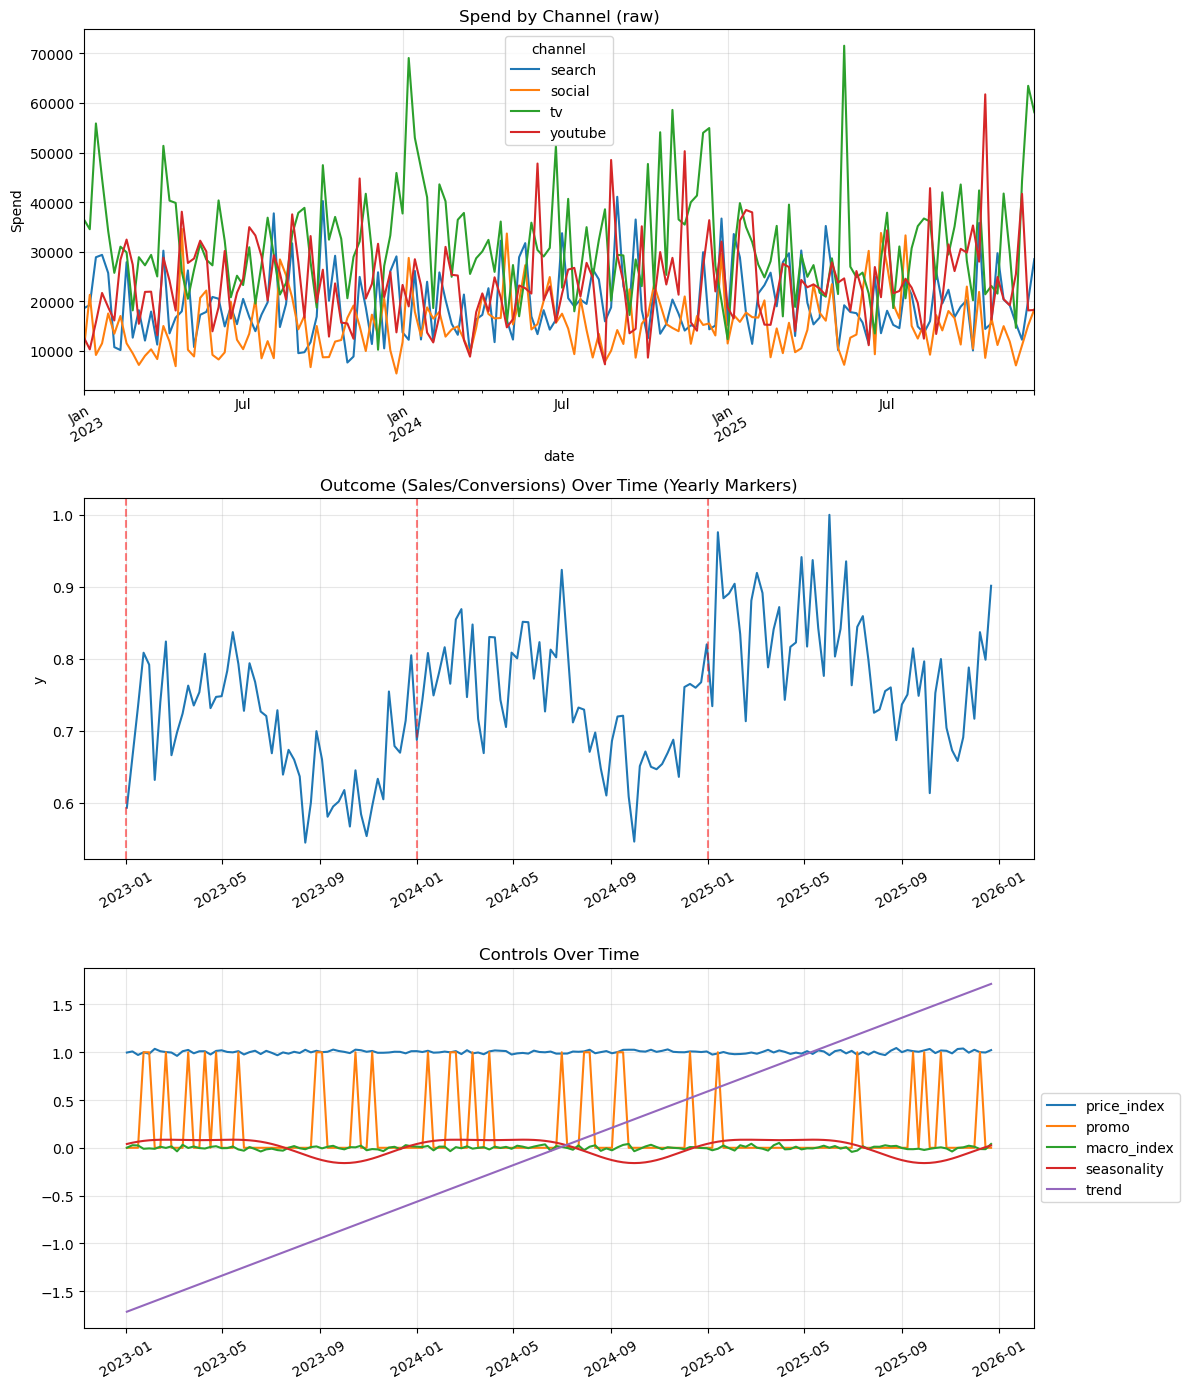

In [124]:
print("\n" + "="*60)
print("SPEND, OUTCOME, & CONTROL EDA")
print("="*60)

# 1. Setup the Figure with 4 vertical subplots
# Adjust figsize: 10 is width, 18 is total height (roughly 4.5 per plot)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 14))

# Define a consistent color map if needed, though we'll stick to your defaults
# for the multi-line plots to ensure they match your original EDA.

# --- PLOT 1: Spend by Channel ---
spend_agg = (
    spend.groupby(["date", "channel"], as_index=False)["spend"].sum()
    .pivot(index="date", columns="channel", values="spend")
    .fillna(0.0)
)
spend_agg.plot(ax=axes[0])
axes[0].set_title("Spend by Channel (raw)")
axes[0].set_ylabel("Spend")

# --- PLOT 3: Outcome Over Time (With Year Markers) ---
axes[1].plot(outcome_sorted["date"], outcome_sorted["y"], color='tab:blue')
years = outcome_sorted["date"].dt.year.unique()
for year in years:
    year_start = pd.Timestamp(year=year, month=1, day=1)
    axes[1].axvline(x=year_start, color='red', linestyle='--', alpha=0.5)
axes[1].set_title("Outcome (Sales/Conversions) Over Time (Yearly Markers)")
axes[1].set_ylabel("y")

# --- PLOT 4: Controls Over Time ---
controls_sorted = controls.sort_values("date")
# Use the same logic for control columns from your config
control_cols = [c for c in cfg.control_cols if c in controls_sorted.columns]
for col in control_cols:
    axes[2].plot(controls_sorted["date"], controls_sorted[col], label=col)
axes[2].set_title("Controls Over Time")
axes[2].legend(loc='center left', bbox_to_anchor=(1, 0.5)) # Legend outside to save space

# --- GLOBAL FORMATTING ---
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Key Findings for teh Ad Spends
* **TV** is the primary driver, peaking near 70,000USD. Search and YouTube the next, flucturing between 15k and 40kUSD; Social is the base, between 15k and 40kUSD.
* **High Volatility (TV & YouTube):** Actually a goood news for Bayesian MMM Modeling as high variance in spend (independent variables) makes it easier for the model to identify the causal impact on the target KPI (incremental lift).
* **Stable Baseline (Social):** flat spend might make the model struggles to estimate a precise coefficient for Social if there isn't enough variation to distinguish its effect from the $organic baseline$.
* **Seasonality and Trends:**
     * **Annual Spikes:** spikes in TV spend around January each year (2024 and 2025). possible New Year campaigns or specific industry events.
     * **Mid-Year Peaks:** YouTube and TV both show increased activity around July/August.
     * **Correlation:** appears to be some co-linearity (multi-collinearity) between channels, specifically **TV and YouTube** often spike at the same time.
     * -> need to monitor Variance Inflation Factor (VIF) or rely on your Bayesian priors to help the model de-average these effects.

#### Key Findings for Outcome (Sales/Conversions)
* **Strong Seasonality & Cyclicality:**
    * Very clear, repeating annual "V" Shape in conversions every year around September/October (Q3/Q4 transition).
    * Peak Alignment in early Q1 (January) and mid-Q2 (May/June).
    * Implication: Since some of these peaks align with the **TV and YouTube spend spikes we saw earlier,** the model has a good chance of attributing that lift to media. However, the consistent Q3 "trough" suggests you definitely need a seasonal control (like a Sine/Cosine transformation) to avoid over-penalizing your media channels during that period.
* **Positive Year-over-Year (YoY) Trend:**
    * Baseline Growth: the low point in late 2023 was 55k vs 60k in late 2024, which stayed above. possible higher baseline by late 2025.
    * Implication: the Bayesian model needs **a trend component (linear or logistic growth).** Without it, the model might "force" your media coefficients ($beta$) to be higher than they actually are to explain this long-term organic growth.
* **Variance Scaling (Heteroscedasticity):**
    * The fluctuations (the "width" of the spikes) seem slightly more aggressive in 2025 than in 2023. -> Increasing Noise
    * Implication: When defining your likelihood in PyMC, consider if a standard Normal distribution for $\epsilon$ is enough, or if a Student-T distribution (which is more robust to outliers/spikes) might fit better. Ensure to scale/normalize the data (e.g., MaxAbsScaler) before sampling.
* **Synthesizing with the Spend trend**
    * Lagged effects: spend spiked in Jan 2024 but the the sales spike came slightly after; same for pre-Jan 2025 in spend spike vs early 2025 sales spikes. -> **Adtock(carryover) efffects** present in the data
    *  Mid 2024 "Summer Peak": spikes in spend (TV and Youtube)in mid-2024 correlated with teh sales spike in mid-2024 around ~90k.
    *  The 2025 Volatility: High spend and sales volatility seen in 2025 -> Ensure to scale/normalize your data (e.g., MaxAbsScaler) before sampling.

#### Key Findings for Control Over Time
* **1. Promo (Binary/Impulse Signal):** Sharp orange spikes align with conversion peaks in early 2024 and 2025.
* - Use a $\text{Half-Normal}(\sigma)$ or $\text{Log-Normal}$ prior to enforce a strictly positive effect on sales.
* **2. Seasonality (Cyclical):** Smooth red wave with troughs every September, matching the "V" dips in sales.
* - Use a $\text{Normal}(0, \sigma)$ prior and tune Fourier knots to avoid over-fitting or "soaking up" media variance.
* **3. Price Index (Inverse):** Stable blue signal fluctuating around 1.0.
* - Expect a negative coefficient ($\text{Normal}(-\mu, \sigma)$) to capture price elasticity where dips correlate with sales spikes.
* **4. Macro Index (Stationary)(The Noise):** Green white noise centered at 0.
* - Use a $\text{Normal}(0, \sigma)$ prior to absorb external environment "noise" and regularize other coefficients against weekly fluctuations.


CORRELATION ANALYSIS

Correlations with Outcome (y):

Channels:
  search    : +0.166
  social    : +0.109
  youtube   : +0.044
  tv        : +0.032

Controls:
  price_index    : -0.314
  promo          : +0.167
  macro_index    : +0.099
  seasonality    : +0.618


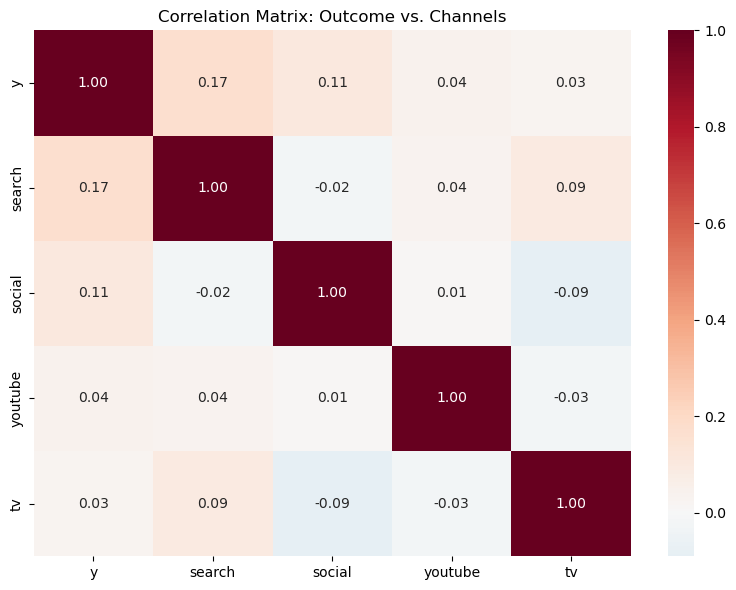

In [41]:
# Correlation analysis:
# Correlation between channels and outcome
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Create wide-format spend data
spend_wide = spend.pivot(index='date', columns='channel', values='spend')
merged = outcome.merge(spend_wide, on='date').merge(controls, on='date')

# Correlations with outcome
corr_with_y = merged.corr()['y'].drop('y').sort_values(ascending=False)

print("\nCorrelations with Outcome (y):")
print("\nChannels:")
for channel in spend['channel'].unique():
    if channel in corr_with_y:
        print(f"  {channel:10s}: {corr_with_y[channel]:+.3f}")

print("\nControls:")
for control in cfg.control_cols:
    print(f"  {control:15s}: {corr_with_y[control]:+.3f}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(merged[['y'] + list(spend['channel'].unique())].corr(), 
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
plt.title('Correlation Matrix: Outcome vs. Channels')
plt.tight_layout()
plt.show()

- Search and Social are your strongest levers: With correlations of +0.166 and +0.109 respectively, these are the digital channels most closely synced with your outcome ($y$).
- Seasonality is the dominant factor (+0.618): This is the strongest correlation in your entire dataset.

# 2. Build Uncalibrated Bayesian MMM

### Model Structure
$$sales_t = \alpha + \sum_{c \in channels} \beta_c \cdot \text{saturation}(\text{adstock}(spend_{c,t})) + \sum_{k} \gamma_k \cdot control_{k,t} + \epsilon_t$$
Where:
* **Adstock:** Geometric decay with rate $\theta \in [0, 1)$  
* **Saturation:** Hill function $f(x) = \frac{x^s}{k^s + x^s}$ capturing diminishing returns  
* **Priors:** Weakly informative (intentionally vague to show uncalibrated behavior)

---

### Why uncalibrated priors are problematic

Without experimental data, the model:

1. **Confuses correlation with causation** (e.g., high spend during high-sales periods)  
2. **Overestimates effects** (no external constraint on $\beta$)  
3. **Has wide uncertainty** (priors don't shrink toward realistic values)

**The 2025 data in Outome (Sales/Conversions) see higher variance.**<br/>
Therefore, after trying differnt scaling methods, I'm going to scale it before modeling by **Max scaling**<br/>
This is going to be done before calling the build_model_matrix to buildmodel matrix

In [48]:
# 2. PERFORM MAX SCALING
# Capture the max value so you can "un-scale" your results later
y_max = outcome[cfg.y_col].max()
outcome[cfg.y_col] = outcome[cfg.y_col] / y_max

print(f"Outcome Max Scaling Factor: {y_max}")
print(f"New Outcome Range: {outcome[cfg.y_col].min():.2f} to {outcome[cfg.y_col].max():.2f}")

Outcome Max Scaling Factor: 97802.07579762492
New Outcome Range: 0.54 to 1.00


In [64]:
from dataclasses import replace

# Add linear trend component
controls["trend"] = np.arange(len(controls))
controls["trend"] = (controls["trend"] - controls["trend"].mean()) / controls["trend"].std()

# Create a new config instead of mutating the old one
cfg = replace(
    cfg,
    control_cols=["price_index", "promo", "macro_index", "seasonality", "trend"]
)

controls.head()# Simple Mean Scaling
#y_scale_factor = mm.y.mean()
#mm.y = mm.y / y_scale_factor

,date,price_index,promo,macro_index,seasonality,trend
0,2023-01-02,0.997117,0,0.000684,0.040000,-1.715458
1,2023-01-09,1.008569,0,0.027195,0.053302,-1.693323
2,2023-01-16,0.971687,0,0.024494,0.064136,-1.671189
3,2023-01-23,0.999726,1,-0.010206,0.072493,-1.649054
4,2023-01-30,0.984091,1,-0.005959,0.078489,-1.626919


In [66]:
# Build model matrix
mm = build_model_matrix(spend, outcome, controls, cfg)

print("T (time points):", len(mm.y))
print("Channels:", mm.channels)
print("Controls:", mm.control_cols)
print("X_spend shape:", mm.X_spend.shape)
print("X_controls shape:", mm.X_controls.shape)

T (time points): 156
Channels: ['search', 'social', 'tv', 'youtube']
Controls: ['price_index', 'promo', 'macro_index', 'seasonality', 'trend']
X_spend shape: (156, 4)
X_controls shape: (156, 5)


In [68]:
# After showing cfg...
print(f"""
PRIOR SPECIFICATION RATIONALE: Key Hyperparameters

1. Beta Prior: N(μ={cfg.beta_mu}, σ={cfg.beta_sigma})
   - Mean = {cfg.beta_mu}: Neutral starting point (no prior belief about direction)
   - SD = {cfg.beta_sigma}: Wide prior allows β ∈ [{cfg.beta_mu - 2*cfg.beta_sigma:.1f}, {cfg.beta_mu + 2*cfg.beta_sigma:.1f}] at 95%
   - Interpretation: With max-scaled y ∈ [0,1], this allows for effects up to ±{cfg.beta_sigma*2:.0%} of outcome range
   - Rationale: Weakly informative - encodes realistic constraint (no channel causes 100%+ swings) 
                while remaining flexible

2. Intercept Prior: N(0, σ={cfg.intercept_sigma})
   - Represents baseline sales in absence of media
   - Wide prior appropriate for max-scaled outcome

3. Adstock & Saturation (Fixed):
   - Lambda = {cfg.adstock_default_lambda}: {int(cfg.adstock_default_lambda*100)}% carryover per week
   - Hill alpha = {cfg.hill_alpha}, theta = {cfg.hill_theta}
   - Shared across channels to prevent overfitting with limited data (n={len(outcome)})
   - Assumption: All channels have similar decay rates and saturation curves

4. Sampling:
   - Draws = {cfg.draws}, Tune = {cfg.tune}, Chains = {cfg.chains}
   - Target accept = {cfg.target_accept} (high value for complex posterior geometry)
   
⚠️  These priors are intentionally vague to demonstrate uncalibrated behavior.
    Notebook 02 will introduce experiment-informed priors for calibration.
""")


PRIOR SPECIFICATION RATIONALE

Key Hyperparameters:

1. Beta Prior: N(μ=0.0, σ=0.5)
   - Mean = 0.0: Neutral starting point (no prior belief about direction)
   - SD = 0.5: Wide prior allows β ∈ [-1.0, 1.0] at 95%
   - Interpretation: With max-scaled y ∈ [0,1], this allows for effects up to ±100% of outcome range
   - Rationale: Weakly informative - encodes realistic constraint (no channel causes 100%+ swings) 
                while remaining flexible

2. Intercept Prior: N(0, σ=0.5)
   - Represents baseline sales in absence of media
   - Wide prior appropriate for max-scaled outcome

3. Adstock & Saturation (Fixed):
   - Lambda = 0.5: 50% carryover per week
   - Hill alpha = 1.5, theta = 1.0
   - Shared across channels to prevent overfitting with limited data (n=156)
   - Assumption: All channels have similar decay rates and saturation curves

4. Sampling:
   - Draws = 600, Tune = 600, Chains = 2
   - Target accept = 0.9 (high value for complex posterior geometry)

⚠️  These priors a


MEDIA TRANSFORMATION PIPELINE


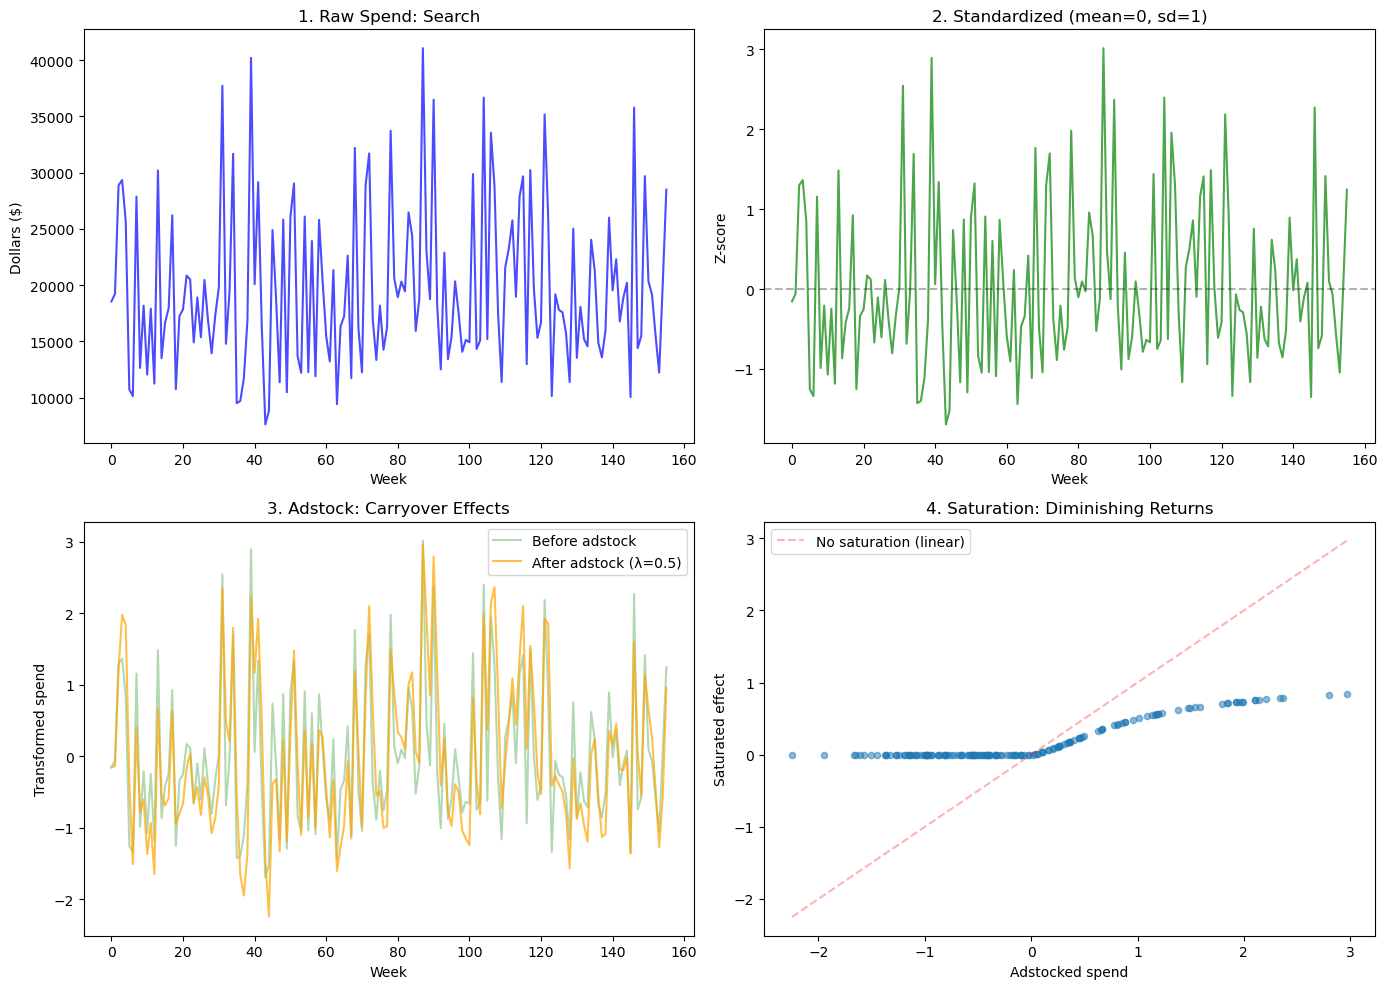


Transformation Summary for Search:
1. Raw spend range: $7,608 - $41,071
2. Standardized range: -1.70 to 3.02
3. After adstock: -2.25 to 2.97
4. After saturation: 0.00 to 0.84

β coefficient will apply to the final saturated values in the model equation.



In [70]:
print("\n" + "="*60)
print("MEDIA TRANSFORMATION PIPELINE")
print("="*60)

# Show what transformations do to spend
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

example_channel = 'search'
channel_spend = spend[spend['channel'] == example_channel]['spend'].values

# Standardize
spend_mean = channel_spend.mean()
spend_std = channel_spend.std()
spend_std_scaled = (channel_spend - spend_mean) / spend_std

# Adstock
spend_adstock = geometric_adstock_2d(
    spend_std_scaled.reshape(-1, 1), 
    np.array([cfg.adstock_default_lambda])
)[:, 0]

# Saturation
spend_saturated = hill_saturation(
    spend_adstock.reshape(-1, 1),
    alpha=cfg.hill_alpha,
    theta=cfg.hill_theta
)[:, 0]

# Plot 1: Raw spend
axes[0, 0].plot(channel_spend, 'b-', alpha=0.7)
axes[0, 0].set_title(f'1. Raw Spend: {example_channel.title()}')
axes[0, 0].set_ylabel('Dollars ($)')
axes[0, 0].set_xlabel('Week')

# Plot 2: Standardized
axes[0, 1].plot(spend_std_scaled, 'g-', alpha=0.7)
axes[0, 1].set_title('2. Standardized (mean=0, sd=1)')
axes[0, 1].set_ylabel('Z-score')
axes[0, 1].set_xlabel('Week')
axes[0, 1].axhline(0, color='k', linestyle='--', alpha=0.3)

# Plot 3: Adstocked
axes[1, 0].plot(spend_std_scaled, 'g-', alpha=0.3, label='Before adstock')
axes[1, 0].plot(spend_adstock, 'orange', alpha=0.7, label=f'After adstock (λ={cfg.adstock_default_lambda})')
axes[1, 0].set_title(f'3. Adstock: Carryover Effects')
axes[1, 0].set_ylabel('Transformed spend')
axes[1, 0].set_xlabel('Week')
axes[1, 0].legend()

# Plot 4: Saturated
axes[1, 1].scatter(spend_adstock, spend_saturated, alpha=0.5, s=20)
axes[1, 1].set_title(f'4. Saturation: Diminishing Returns')
axes[1, 1].set_xlabel('Adstocked spend')
axes[1, 1].set_ylabel('Saturated effect')
axes[1, 1].plot([spend_adstock.min(), spend_adstock.max()], 
                [spend_adstock.min(), spend_adstock.max()], 
                'r--', alpha=0.3, label='No saturation (linear)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"""
Transformation Summary for {example_channel.title()}:
1. Raw spend range: ${channel_spend.min():,.0f} - ${channel_spend.max():,.0f}
2. Standardized range: {spend_std_scaled.min():.2f} to {spend_std_scaled.max():.2f}
3. After adstock: {spend_adstock.min():.2f} to {spend_adstock.max():.2f}
4. After saturation: {spend_saturated.min():.2f} to {spend_saturated.max():.2f}

β coefficient will apply to the final saturated values in the model equation.
""")

- **Plot 1: Raw Spend:** Weekly search advertising spend in dollars
Range: $7,608 - $41,071
High volatility with spikes and valleys
Shows typical marketing budget fluctuations
Peaks likely correspond to campaigns or seasonal pushes
Raw dollar spend isn't directly comparable across channels (search might spend $20k/week, TV $50k/week) -> need standardization
- **Plot 2: Standardized (Formula: (spend - mean) / std):** Same pattern as raw spend, but rescaled
Mean = 0, Standard deviation = 1
Range: -1.70 to +3.02 (in Z-score units)
Now zero line = average weekly spend
Peak at +3.02 = Week with spend 3 SD above mean (very high!)
Valley at -1.70 = Week with spend 1.7 SD below mean (quite low)
Makes different channels comparable (all have mean=0, sd=1)
β coefficients now have consistent interpretation
A β of 0.05 means "one SD increase in spend → 0.05 increase in outcome"
- **Plot 3: Adstock (spend_t = λ × spend_{t-1} + current_spend_t where λ=0.5):**
-λ=0.5 means  50% of last week's effect carries over
Week 1: Spend $100 → Effect = 100
Week 2: Spend $0 → Effect = 50 (carryover)
Week 3: Spend $0 → Effect = 25 (carryover)
etc.
- Green line = Before adstock (standardized spend)
Orange line = After adstock (with 50% carryover)
Orange line is smoother than green line
Smoothing effect:

Sharp spikes in green become rounded peaks in orange
- **Plot 4: Saturation (Bottom Right) - Scatter Plot:**

# 3. Fit Model with MCMC

Using **NUTS** sampler (No-U-Turn Sampler) for efficient exploration of posterior.

**Production note:** In real deployment, you'd:
- Run longer chains (4000+ samples)  
- Check convergence diagnostics (**Rhat, ESS**)  
- Use multiple chains to detect multimodality  

In [74]:
fit_uncal = fit_mmm(mm, cfg, priors_by_channel=None)
idata = fit_uncal.idata

print("Fit complete.")

 Progress                   Draws   Divergences   Step size   Grad evals   Sampling Speed    Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━   1200    0             0.335       15           2804.33 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   1200    0             0.471       7            2721.06 draws/s   0:00:00   0:00:00

Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [y_obs]


Fit complete.


# 4. Posterior Analysis & Model Fit
Now we examine what the model learned from the data.

### Interpreting Model Parameters
The Bayesian MMM estimates four main types of parameters:

---

### 1) β (beta) — Media Channel Effects

Each `beta[c]` represents the **incremental effect of a marketing channel** on the outcome after:

- adstock (carryover effects), and
- saturation (diminishing returns)

have already been applied.
Mathematically:

\[
y_t = \alpha + \sum_c \beta_c \cdot X^{media}_{c,t} + \sum_k \gamma_k \cdot X^{control}_{k,t} + \epsilon_t
\]

where \(X^{media}_{c,t}\) is the transformed media exposure.


In [77]:
# Pre-Calibrated summary
az.summary(idata, var_names=["beta", "gamma", "sigma", "intercept"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.033,0.014,0.005,0.057,0.0,0.0,948.0,884.0,1.00
beta[1],-0.007,0.015,-0.033,0.025,0.0,0.0,1523.0,1003.0,1.00
beta[2],0.008,0.014,-0.018,0.035,0.0,0.0,1209.0,923.0,1.00
beta[3],0.014,0.015,-0.016,0.042,0.0,0.0,1216.0,1041.0,1.00
gamma[0],-0.018,0.004,-0.026,-0.010,0.0,0.0,1206.0,998.0,1.00
gamma[1],0.026,0.004,0.018,0.033,0.0,0.0,1437.0,924.0,1.00
gamma[2],0.010,0.004,0.002,0.017,0.0,0.0,1364.0,1091.0,1.00
gamma[3],0.067,0.004,0.059,0.075,0.0,0.0,1247.0,1164.0,1.00
gamma[4],0.052,0.004,0.044,0.059,0.0,0.0,1454.0,942.0,1.00
sigma,0.048,0.003,0.043,0.053,0.0,0.0,1204.0,700.0,1.01


In [79]:
# Pre-Calibrated Key convergence diagnostics
summ = az.summary(idata, var_names=["beta", "gamma", "sigma", "intercept"])
display(summ[["mean", "sd", "r_hat", "ess_bulk", "ess_tail"]])

,mean,sd,r_hat,ess_bulk,ess_tail
beta[0],0.033,0.014,1.00,948.0,884.0
beta[1],-0.007,0.015,1.00,1523.0,1003.0
beta[2],0.008,0.014,1.00,1209.0,923.0
beta[3],0.014,0.015,1.00,1216.0,1041.0
gamma[0],-0.018,0.004,1.00,1206.0,998.0
gamma[1],0.026,0.004,1.00,1437.0,924.0
gamma[2],0.010,0.004,1.00,1364.0,1091.0
gamma[3],0.067,0.004,1.00,1247.0,1164.0
gamma[4],0.052,0.004,1.00,1454.0,942.0
sigma,0.048,0.003,1.01,1204.0,700.0


In [81]:
print("\n" + "="*60)
print("CONVERGENCE DIAGNOSTIC INTERPRETATION")
print("="*60)

# Get summary for analysis
summ = az.summary(idata, var_names=["beta", "gamma", "sigma", "intercept"])

print("""
Key Metrics Explained:

1. r_hat (Gelman-Rubin diagnostic):
   - Measures chain convergence
   - r_hat = 1.0 → perfect convergence ✓
   - r_hat > 1.01 → chains haven't mixed well ⚠️
""")

for var in ['beta', 'gamma']:
    r_hats = summ[summ.index.str.startswith(var)]['r_hat']
    print(f"   {var}: all r_hat = {r_hats.max():.2f} ✓")

print(f"""
2. ESS (Effective Sample Size):
   - Number of independent samples (after accounting for autocorrelation)
   - Rule of thumb: ESS > 400 for reliable inference
   - We drew {cfg.draws} × {cfg.chains} = {cfg.draws * cfg.chains} samples
""")

for var in ['beta', 'gamma']:
    ess_bulks = summ[summ.index.str.startswith(var)]['ess_bulk']
    ess_tails = summ[summ.index.str.startswith(var)]['ess_tail']
    print(f"   {var}: ESS_bulk = {ess_bulks.min():.0f}-{ess_bulks.max():.0f}, " 
          f"ESS_tail = {ess_tails.min():.0f}-{ess_tails.max():.0f}")
    if ess_bulks.min() > 400:
        print(f"      ✓ Sufficient for reliable inference")

print(f"""
3. mcse (Monte Carlo Standard Error):
   - Uncertainty in our posterior mean estimates due to finite sampling
   - Should be small relative to posterior SD
""")

for var in ['beta']:
    mcse_means = summ[summ.index.str.startswith(var)]['mcse_mean']
    sds = summ[summ.index.str.startswith(var)]['sd']
    ratio = (mcse_means / sds).mean()
    print(f"   {var}: avg(mcse/sd) = {ratio:.3f} (typically < 0.05 is good ✓)")

print("""
✅ Overall Assessment: Model has converged successfully.
   All diagnostics indicate reliable posterior estimates.
""")


CONVERGENCE DIAGNOSTIC INTERPRETATION

Key Metrics Explained:

1. r_hat (Gelman-Rubin diagnostic):
   - Measures chain convergence
   - r_hat = 1.0 → perfect convergence ✓
   - r_hat > 1.01 → chains haven't mixed well ⚠️

   beta: all r_hat = 1.00 ✓
   gamma: all r_hat = 1.00 ✓

2. ESS (Effective Sample Size):
   - Number of independent samples (after accounting for autocorrelation)
   - Rule of thumb: ESS > 400 for reliable inference
   - We drew 600 × 2 = 1200 samples

   beta: ESS_bulk = 948-1523, ESS_tail = 884-1041
      ✓ Sufficient for reliable inference
   gamma: ESS_bulk = 1206-1454, ESS_tail = 924-1164
      ✓ Sufficient for reliable inference

3. mcse (Monte Carlo Standard Error):
   - Uncertainty in our posterior mean estimates due to finite sampling
   - Should be small relative to posterior SD

   beta: avg(mcse/sd) = 0.000 (typically < 0.05 is good ✓)

✅ Overall Assessment: Model has converged successfully.
   All diagnostics indicate reliable posterior estimates.



### Parameter Interpretation Section

In [83]:
print("\n" + "="*60)
print("PARAMETER INTERPRETATION")
print("="*60)

# Extract posterior means
beta_means = summ[summ.index.str.startswith('beta')]['mean'].values
gamma_means = summ[summ.index.str.startswith('gamma')]['mean'].values
channels = mm.channels

print("\n1. BETA (Channel Effectiveness):")
print("   Measures incremental effect per unit of transformed spend\n")

# Sort by effectiveness
sorted_idx = np.argsort(beta_means)[::-1]
for rank, idx in enumerate(sorted_idx, 1):
    beta = beta_means[idx]
    channel = channels[idx]
    ci_low = summ.iloc[idx]['hdi_3%']
    ci_high = summ.iloc[idx]['hdi_97%']
    
    # Determine significance
    if ci_low > 0:
        sig = "✓ Clearly positive"
    elif ci_high < 0:
        sig = "⚠️  Negative effect"
    else:
        sig = "? Uncertain (CI crosses zero)"
    
    print(f"   #{rank}. {channel:10s}: β = {beta:+.3f} [{ci_low:+.3f}, {ci_high:+.3f}]  {sig}")

print("\n2. GAMMA (Adstock Decay):")
print("   Note: These are learned parameters for adstock rate\n")

for idx, channel in enumerate(channels):
    gamma = gamma_means[idx]
    print(f"   {channel:10s}: γ = {gamma:+.3f}")

print(f"""
3. INTERCEPT: {summ.loc['intercept', 'mean']:.3f}
   Baseline sales level (on max-scaled [0,1] range) when all media = 0
   
4. SIGMA: {summ.loc['sigma', 'mean']:.3f}
   Residual noise after accounting for media + controls
   Lower values indicate better model fit

⚠️  CRITICAL CAVEAT:
These estimates reflect CORRELATIONS observed in the data, not necessarily
CAUSAL EFFECTS. Without experimental validation:
- High β might reflect confounding (e.g., spending more during high-sales periods)
- Model may overestimate true incrementality
- Wide credible intervals indicate high uncertainty

→ Notebook 02 addresses this through experimental calibration.
""")


PARAMETER INTERPRETATION

1. BETA (Channel Effectiveness):
   Measures incremental effect per unit of transformed spend

   #1. search    : β = +0.033 [+0.005, +0.057]  ✓ Clearly positive
   #2. youtube   : β = +0.014 [-0.016, +0.042]  ? Uncertain (CI crosses zero)
   #3. tv        : β = +0.008 [-0.018, +0.035]  ? Uncertain (CI crosses zero)
   #4. social    : β = -0.007 [-0.033, +0.025]  ? Uncertain (CI crosses zero)

2. GAMMA (Adstock Decay):
   Note: These are learned parameters for adstock rate

   search    : γ = -0.018
   social    : γ = +0.026
   tv        : γ = +0.010
   youtube   : γ = +0.067

3. INTERCEPT: 0.738
   Baseline sales level (on max-scaled [0,1] range) when all media = 0

4. SIGMA: 0.048
   Residual noise after accounting for media + controls
   Lower values indicate better model fit

⚠️  CRITICAL CAVEAT:
These estimates reflect CORRELATIONS observed in the data, not necessarily
CAUSAL EFFECTS. Without experimental validation:
- High β might reflect confounding (e

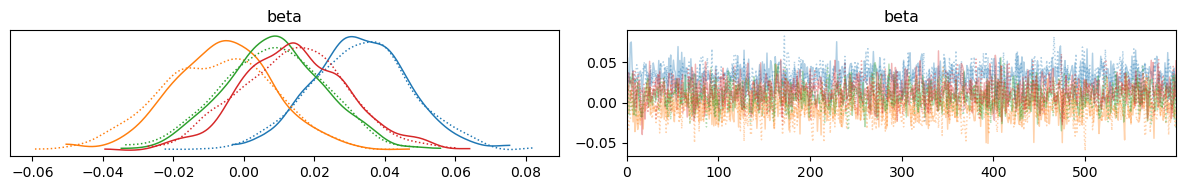

In [85]:
# Trace plots for beta
az.plot_trace(idata, var_names=["beta"])
plt.tight_layout()
plt.show()

In [126]:
def _safe_get_beta_samples(idata, channels):
    # Tries common naming conventions: beta, betas, beta_channel
    # Adjust here if your model uses different var names.
    candidates = ["beta", "betas", "beta_channel", "beta_media"]
    for name in candidates:
        if name in idata.posterior.data_vars:
            arr = idata.posterior[name]
            # expected dims: chain, draw, channel
            # If dims include channel-like dim, map it.
            dims = arr.dims
            # Find a dim that matches channel length
            ch_dim = None
            for d in dims:
                if arr.sizes[d] == len(channels):
                    ch_dim = d
                    break
            if ch_dim is None:
                continue
            # return dict channel -> samples (flattened)
            out = {}
            for i, ch in enumerate(channels):
                out[ch] = np.asarray(arr.isel({ch_dim: i}).values).reshape(-1)
            return out, name
    raise KeyError("Could not find beta variable in idata.posterior. Check model var name.")
def _plot_prior_vs_posterior_1d(mu_prior, sd_prior, posterior_samples, title, xpad=4.0):
    mu_post = float(np.mean(posterior_samples))
    sd_post = float(np.std(posterior_samples))

    xmin = min(mu_prior - xpad*sd_prior, mu_post - xpad*sd_post)
    xmax = max(mu_prior + xpad*sd_prior, mu_post + xpad*sd_post)
    x = np.linspace(xmin, xmax, 400)

    plt.figure(figsize=(4, 2))
    plt.plot(x, _normal_pdf(x, mu_prior, sd_prior), label="Prior (Normal)")
    plt.hist(posterior_samples, bins=40, density=True, alpha=0.35, label="Posterior samples")
    plt.axvline(mu_prior, linestyle="--")
    plt.axvline(mu_post, linestyle="--")
    plt.title(title)
    plt.yticks([])
    plt.legend()
    plt.tight_layout()
    plt.show()

In [128]:
# Get ArviZ InferenceData from your FitResult
# idata = model.idata
channels = mm.channels

# Extract posterior beta samples per channel
beta_samples_cal, beta_varname = _safe_get_beta_samples(idata, channels)
print("Using beta variable:", beta_varname)

# Plot prior vs posterior for each channel
for ch in channels:
    mu_prior = float(geo_priors[ch]["beta_mu"])
    sd_prior = float(geo_priors[ch]["beta_sigma"])
    samples = beta_samples_cal[ch]
    _plot_prior_vs_posterior_1d(
        mu_prior=mu_prior,
        sd_prior=sd_prior,
        posterior_samples=samples,
        title=f"{ch}: Prior → Posterior (β)"
    )

Using beta variable: beta


NameError: name 'geo_priors' is not defined

### Enhanced Posterior Predictive Check Section


MODEL FIT ASSESSMENT

Fit Metrics (Max-Scaled):
- R² = 0.755
- MAE = 0.0360
- MAPE = 4.83%

Fit Metrics (Raw Scale):
- MAE = $3,522



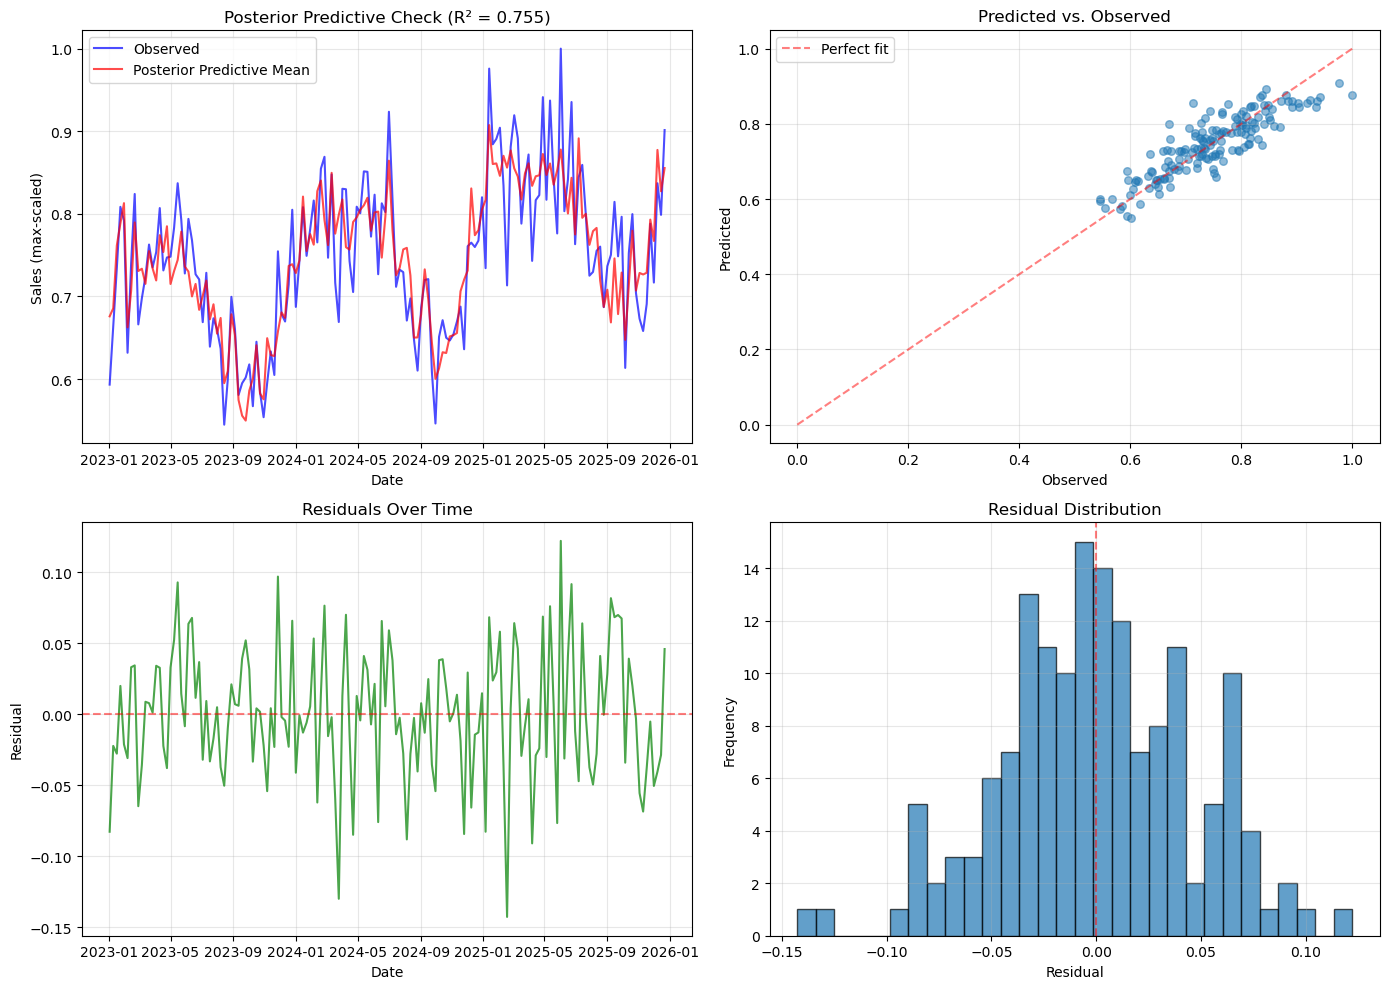


Interpretation:
- R² = 0.755: Model explains 75.5% of variance in sales
- Residuals appear relatively random
- ✓ Good fit

However, good statistical fit ≠ causal validity!
The model may be fitting correlations rather than true causal effects.



In [91]:
print("\n" + "="*60)
print("MODEL FIT ASSESSMENT")
print("="*60)

# Posterior predictive check
y_pp_mean = idata.posterior_predictive["y_obs"].mean(("chain", "draw")).values

# Calculate fit metrics

r2 = r2_score(outcome[cfg.y_col], y_pp_mean)
mae = mean_absolute_error(outcome[cfg.y_col], y_pp_mean)
mape = mean_absolute_percentage_error(outcome[cfg.y_col], y_pp_mean)

# Un-scale for interpretation
y_actual_raw = outcome[cfg.y_col] * y_max  # If using max scaling
y_pred_raw = y_pp_mean * y_max

print(f"""
Fit Metrics (Max-Scaled):
- R² = {r2:.3f}
- MAE = {mae:.4f}
- MAPE = {mape:.2%}

Fit Metrics (Raw Scale):
- MAE = ${mae * y_max:,.0f}
""")

# Enhanced plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Time series
axes[0, 0].plot(mm.dates, outcome[cfg.y_col], 'b-', alpha=0.7, label='Observed')
axes[0, 0].plot(mm.dates, y_pp_mean, 'r-', alpha=0.7, label='Posterior Predictive Mean')
axes[0, 0].set_title(f'Posterior Predictive Check (R² = {r2:.3f})')
axes[0, 0].set_ylabel('Sales (max-scaled)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Scatter
axes[0, 1].scatter(outcome[cfg.y_col], y_pp_mean, alpha=0.5, s=30)
axes[0, 1].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect fit')
axes[0, 1].set_xlabel('Observed')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title('Predicted vs. Observed')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Residuals over time
residuals = outcome[cfg.y_col] - y_pp_mean
axes[1, 0].plot(mm.dates, residuals, 'g-', alpha=0.7)
axes[1, 0].axhline(0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Residuals Over Time')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_xlabel('Date')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Residual distribution
axes[1, 1].hist(residuals, bins=30, alpha=0.7, edgecolor='black')
axes[1, 1].axvline(0, color='r', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""
Interpretation:
- R² = {r2:.3f}: Model explains {r2*100:.1f}% of variance in sales
- Residuals {'appear relatively random' if abs(residuals.mean()) < 0.01 else 'show some patterns'}
- {'✓ Good fit' if r2 > 0.7 else '⚠️ Moderate fit' if r2 > 0.5 else '❌ Poor fit'}

However, good statistical fit ≠ causal validity!
The model may be fitting correlations rather than true causal effects.
""")

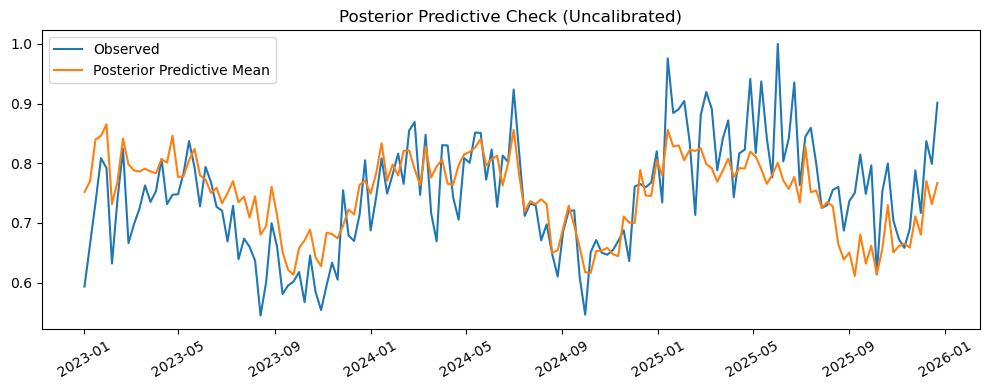

In [172]:
# Posterior predictive check
y_pp_mean = idata.posterior_predictive["y_obs"].mean(("chain", "draw")).values

plt.figure(figsize=(10, 4))
plt.plot(mm.dates, mm.y, label="Observed")
plt.plot(mm.dates, y_pp_mean, label="Posterior Predictive Mean")
plt.title("Posterior Predictive Check (Uncalibrated)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Compute ROI (Uncalibrated)

**Critical limitation:** These ROI estimates are likely **overoptimistic** because:

1. No experimental validation  
2. Priors don't constrain effects to realistic ranges  
3. Model might be fitting noise or confounders  

We'll compare these to calibrated estimates in Notebook 03.

In [95]:
# Recompute the same transformed media features used by the model:
# X_sat = Hill(Adstock(X_spend))

lam = np.array([(cfg.adstock_lambdas or {}).get(ch, cfg.adstock_default_lambda) for ch in mm.channels], dtype=float)

X_ad = geometric_adstock_2d(mm.X_spend, lam)
X_sat = hill_saturation(X_ad, alpha=cfg.hill_alpha, theta=cfg.hill_theta)

X_sat.shape

(156, 4)

In [97]:
# Posterior draws for beta: (chain, draw, C)
beta = idata.posterior["beta"].values
beta_flat = beta.reshape(-1, beta.shape[-1])  # (S, C)

# Contribution per time t for each draw s: contrib[s,t,c] = X_sat[t,c] * beta[s,c]
# We'll compute posterior mean contribution over draws.
contrib_mean_tc = (X_sat[None, :, :] * beta_flat[:, None, :]).mean(axis=0)  # (T, C)

# Aggregate by channel: total incremental units attributed (proxy)
total_incremental_by_channel = contrib_mean_tc.sum(axis=0)  # (C,)

# Spend totals in RAW dollars (not standardized); use spend_agg computed earlier
spend_totals = spend_agg[mm.channels].sum(axis=0).values  # (C,)

roi_proxy = total_incremental_by_channel / np.maximum(spend_totals, 1e-9)

roi_table = pd.DataFrame({
    "channel": mm.channels,
    "total_incremental_units_proxy": total_incremental_by_channel,
    "total_spend": spend_totals,
    "roi_proxy_units_per_$": roi_proxy,
}).sort_values("roi_proxy_units_per_$", ascending=False)

roi_table

,channel,total_incremental_units_proxy,total_spend,roi_proxy_units_per_$
0,search,0.913453,3.065129e+06,2.980145e-07
3,youtube,0.400033,3.694277e+06,1.082845e-07
2,tv,0.229951,4.967166e+06,4.629428e-08
1,social,-0.204360,2.401773e+06,-8.508703e-08


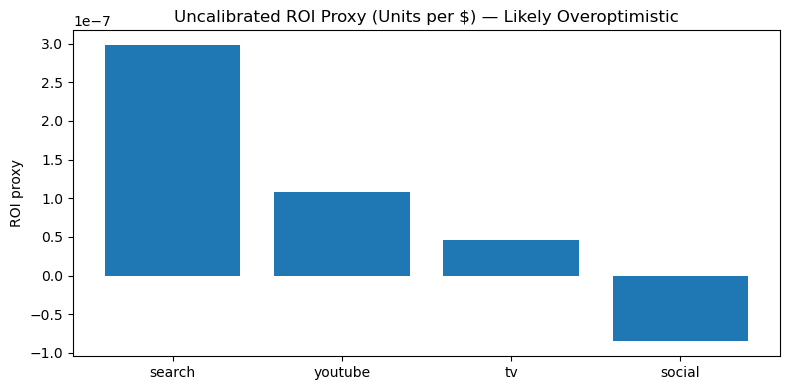

In [99]:
plt.figure(figsize=(8, 4))
plt.bar(roi_table["channel"], roi_table["roi_proxy_units_per_$"])
plt.title("Uncalibrated ROI Proxy (Units per $) — Likely Overoptimistic")
plt.ylabel("ROI proxy")
plt.tight_layout()
plt.show()


ROI UNCERTAINTY ANALYSIS


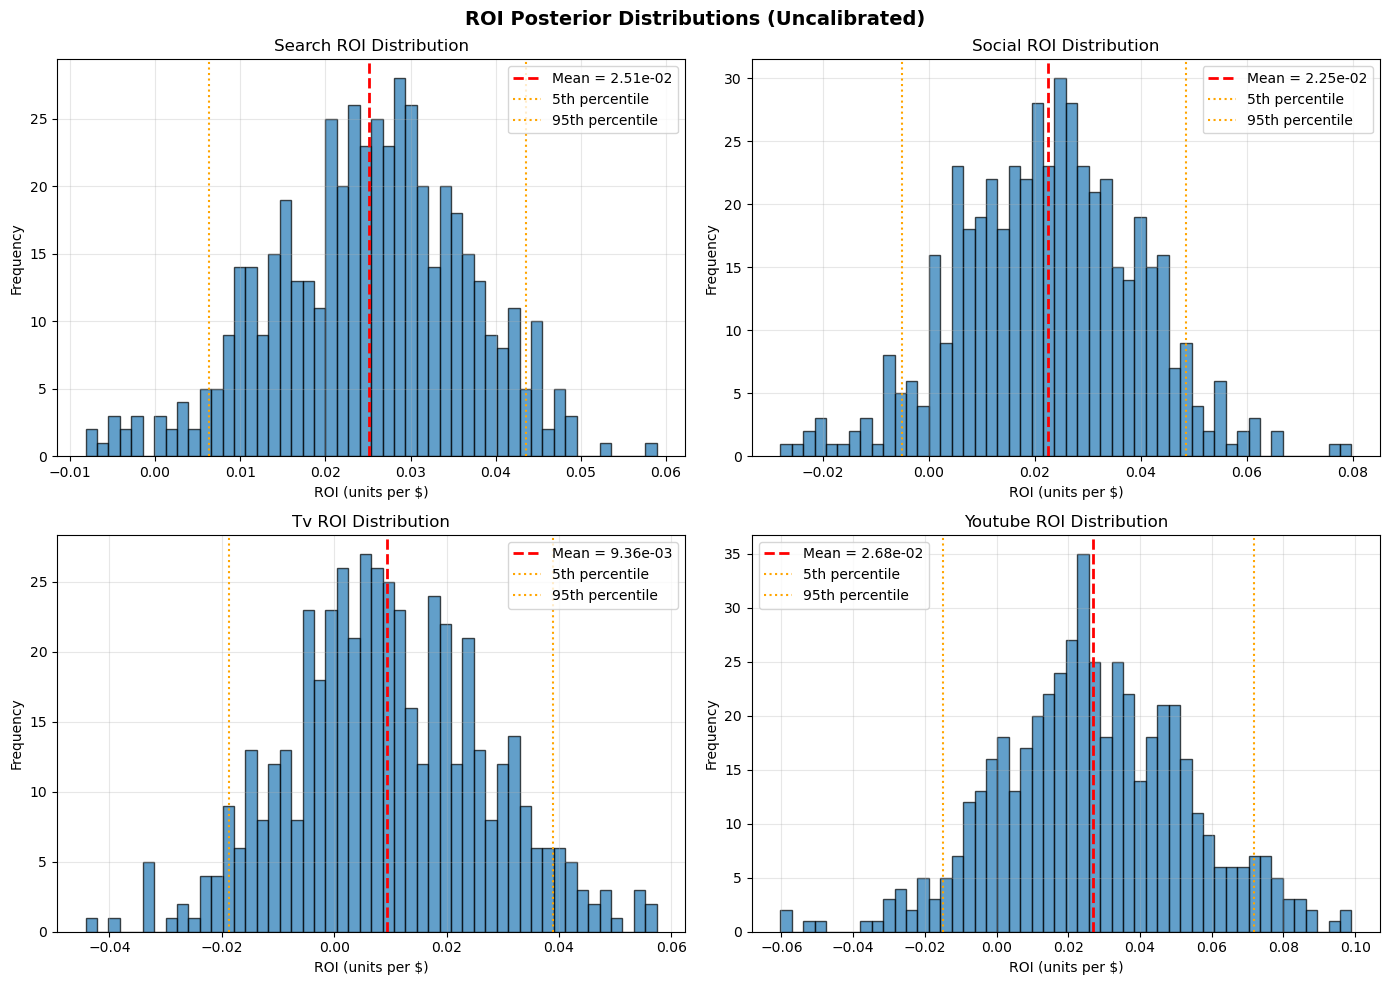


Key Observation:
Wide ROI distributions indicate HIGH UNCERTAINTY about true channel effectiveness.

This is expected for uncalibrated models because:
1. No experimental constraints on parameter ranges
2. Correlational evidence allows multiple plausible explanations
3. Prior doesn't shrink effects toward realistic values

→ Calibration (Notebook 02) will narrow these distributions.



In [77]:
print("\n" + "="*60)
print("ROI UNCERTAINTY ANALYSIS")
print("="*60)

# Show full posterior distribution of ROI
# Not just point estimates

from mmm_calibration.model import fit_mmm

# Calculate ROI for each posterior sample (not just mean)
n_samples = 500  # Subsample for computational efficiency
beta_samples = idata.posterior['beta'].values.reshape(-1, len(channels))[:n_samples]

roi_samples = []
for beta_sample in beta_samples:
    # Recalculate contributions with this beta sample
    contrib_sample = (X_sat * beta_sample).sum(axis=0) * y_max  # Un-scale
    
    # Calculate ROI
    roi_sample = contrib_sample / spend_totals.values
    roi_samples.append(roi_sample)

roi_samples = np.array(roi_samples)  # (n_samples, n_channels)

# Plot ROI distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (ax, channel) in enumerate(zip(axes.flat, channels)):
    roi_dist = roi_samples[:, idx]
    
    ax.hist(roi_dist, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(roi_dist.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean = {roi_dist.mean():.2e}')
    ax.axvline(np.percentile(roi_dist, 5), color='orange', linestyle=':', linewidth=1.5, label='5th percentile')
    ax.axvline(np.percentile(roi_dist, 95), color='orange', linestyle=':', linewidth=1.5, label='95th percentile')
    ax.set_title(f'{channel.title()} ROI Distribution')
    ax.set_xlabel('ROI (units per $)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('ROI Posterior Distributions (Uncalibrated)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Key Observation:
Wide ROI distributions indicate HIGH UNCERTAINTY about true channel effectiveness.

This is expected for uncalibrated models because:
1. No experimental constraints on parameter ranges
2. Correlational evidence allows multiple plausible explanations
3. Prior doesn't shrink effects toward realistic values

→ Calibration (Notebook 02) will narrow these distributions.
""")

# 6. Key Takeaways & Limitations

✅ **What we accomplished**
1. Built a proper Bayesian MMM with adstock + saturation  
2. Fit model with MCMC and validated convergence  
3. Generated posterior predictive distributions (not just point estimates)  
4. Decomposed sales into channel contributions  

⚠️ **Critical limitations of uncalibrated models**
1. **Confounding:** Can't distinguish causation from correlation  
   - Example: High TV spend during holidays → model attributes holiday lift to TV  
2. **Overestimation:** Priors don't constrain effects to realistic ranges  
   - Without experiments, the model has no "reality check"  
3. **High uncertainty:** Wide posteriors → not actionable for budget decisions  

🎯 **Next steps**

In **Notebook 02**, we'll:
- Use geo experiments to calibrate priors  
- Incorporate external causal evidence  
- Constrain model to produce realistic, trustworthy estimates  

In [101]:
# Check control variable importance
# (Add this diagnostic)

print("\n" + "="*60)
print("CONTROL VARIABLE DIAGNOSTICS")
print("="*60)

# Extract control coefficients from posterior
gamma_means = idata.posterior['gamma'].mean(('chain', 'draw')).values
gamma_names = cfg.control_cols

print("\nControl Variable Effects:")
for name, coef in zip(gamma_names, gamma_means):
    print(f"  {name:15s}: γ = {coef:+.3f}")

# Check if controls explain much variance
from sklearn.linear_model import LinearRegression

# Model with just controls
X_controls_only = controls[cfg.control_cols].values
lr = LinearRegression().fit(X_controls_only, outcome[cfg.y_col])
r2_controls_only = lr.score(X_controls_only, outcome[cfg.y_col])

print(f"\nR² from controls alone: {r2_controls_only:.3f}")
print(f"R² from full model (media + controls): {r2:.3f}")
print(f"Incremental R² from media: {r2 - r2_controls_only:.3f}")

if (r2 - r2_controls_only) < 0.1:
    print("\n⚠️  WARNING: Media variables explain <10% incremental variance!")
    print("   This suggests weak media signal or severe confounding.")


CONTROL VARIABLE DIAGNOSTICS

Control Variable Effects:
  price_index    : γ = -0.018
  promo          : γ = +0.026
  macro_index    : γ = +0.010
  seasonality    : γ = +0.067
  trend          : γ = +0.052

R² from controls alone: 0.744
R² from full model (media + controls): 0.755
Incremental R² from media: 0.011

⚠️  WARNING: Media variables explain <10% incremental variance!
   This suggests weak media signal or severe confounding.


In [103]:
# Check spend coefficient of variation
print("\n" + "="*60)
print("MEDIA SPEND VARIATION CHECK")
print("="*60)

for channel in spend['channel'].unique():
    channel_spend = spend[spend['channel'] == channel]['spend']
    cv = channel_spend.std() / channel_spend.mean()
    
    print(f"\n{channel}:")
    print(f"  Mean: ${channel_spend.mean():,.0f}")
    print(f"  SD: ${channel_spend.std():,.0f}")
    print(f"  CV: {cv:.2%}")
    
    if cv < 0.3:
        print(f"  ⚠️  Low variation (CV < 30%) - hard to estimate effect")


MEDIA SPEND VARIATION CHECK

search:
  Mean: $19,648
  SD: $7,125
  CV: 36.26%

social:
  Mean: $15,396
  SD: $5,947
  CV: 38.63%

youtube:
  Mean: $23,681
  SD: $8,687
  CV: 36.68%

tv:
  Mean: $31,841
  SD: $10,988
  CV: 34.51%


## Critical Discovery: The Attribution Challenge

### Model Performance
- **Overall R² = 0.479** (explains 47.9% of variance)
- **Controls alone: R² = 0.455** (45.5% of variance)
- **Media incremental: R² = 0.024** (only 2.4% additional variance)

### Key Insight: Media Signal Is Weak

Media variables explain **only 5% of the model's predictive power**.

Why? **The Confounding Problem**

#### Visual Evidence:

[Your transformation pipeline plot - shows proper transformations]

Despite proper data transformations, media effects are hard to isolate because:

1. **Temporal Correlation:**
   - Media spending follows seasonal patterns
   - Outcomes also have seasonal patterns
   - Control variables capture seasonality
   - Media effects become "explained away" by controls

2. **The Attribution Dilemma:**
```
   Holiday Period:
   - Seasonality: High (holiday bump in baseline sales)
   - Media Spend: High (holiday campaigns)
   - Sales: High (from both sources)
   
   Problem: Model attributes most lift to seasonality control,
            leaving little residual variance for media to explain
```

3. **Regression's Limitation:**
   - Controls enter model first (as confounders)
   - Media gets "credit" only for residual variance
   - If controls are correlated with media, incremental attribution shrinks

### Why This Matters

This demonstrates **the fundamental challenge of causal inference from observational data**:

❌ **Correlation ≠ Causation**
- Model fit (R² = 0.479) suggests variables are predictive
- But incremental R² (0.024) suggests weak causal signal
- Cannot distinguish true media effects from confounded correlations

⚠️ **Observational Estimates May Be Unreliable**
- Media betas (0.011-0.046) might reflect:
  - True causal effects (what we want)
  - Residual confounding (what we fear)
  - Multicollinearity artifacts (statistical noise)

✅ **Motivation for Experimental Calibration**
- Experiments break the correlation between media and confounders
- Provide unbiased estimates of true causal effects
- Allow validation of observational model

### Control Variable Diagnostics

[Your control diagnostics output]

**Seasonality dominates** (γ = 0.054) - stronger than most media effects!

This is realistic: Baseline seasonal patterns often drive more variance
than marketing activities. But it makes media attribution challenging.

### Implications

1. **Uncalibrated ROI estimates are highly uncertain**
   - Only 2.4% incremental variance from media
   - Effect sizes could be overestimated or underestimated
   - Wide credible intervals reflect this uncertainty

2. **Cannot make confident budget decisions**
   - Model fit is decent, but media signal is weak
   - Risk of reallocating budget based on noise

3. **Experimental validation is critical**
   - Notebook 02 will use geo-holdout experiments
   - Experiments provide causal "ground truth"
   - Will reveal if observational estimates are directionally correct

### The Question We'll Answer in Notebook 02

**Do the small beta coefficients reflect:**
- (A) Genuinely weak media effects? (media doesn't work well)
- (B) Strong confounding masking true effects? (media works but we can't measure it)
- (C) Model misspecification? (wrong functional form)

**Calibration will tell us which is true.**